--- Training SLP for OR Gate ---
Update 1 : Weights = [0. 0.], Bias = -0.10 | Caused by input [0 0]
Update 2 : Weights = [0.  0.1], Bias = 0.00 | Caused by input [0 1]
Update 3 : Weights = [0.  0.1], Bias = -0.10 | Caused by input [0 0]
Update 4 : Weights = [0.1 0.1], Bias = 0.00 | Caused by input [1 0]
Update 5 : Weights = [0.1 0.1], Bias = -0.10 | Caused by input [0 0]
Converged at epoch 4.



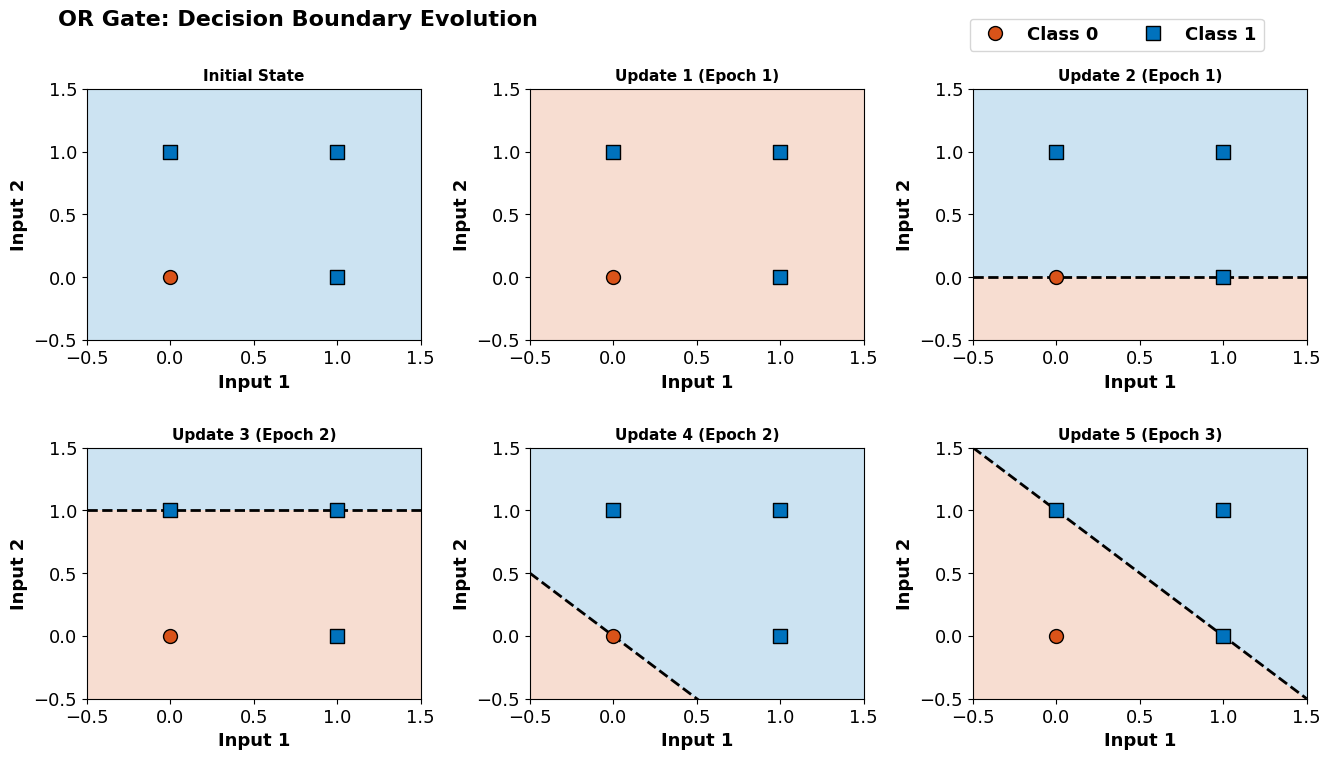

--- Training SLP for AND Gate ---
Update 1 : Weights = [0. 0.], Bias = -0.10 | Caused by input [0 0]
Update 2 : Weights = [0.1 0.1], Bias = 0.00 | Caused by input [1 1]
Update 3 : Weights = [0.1 0.1], Bias = -0.10 | Caused by input [0 0]
Update 4 : Weights = [0.1 0. ], Bias = -0.20 | Caused by input [0 1]
Update 5 : Weights = [0.2 0.1], Bias = -0.10 | Caused by input [1 1]
Update 6 : Weights = [0.2 0. ], Bias = -0.20 | Caused by input [0 1]
Update 7 : Weights = [0.1 0. ], Bias = -0.30 | Caused by input [1 0]
Update 8 : Weights = [0.2 0.1], Bias = -0.20 | Caused by input [1 1]
Converged at epoch 4.



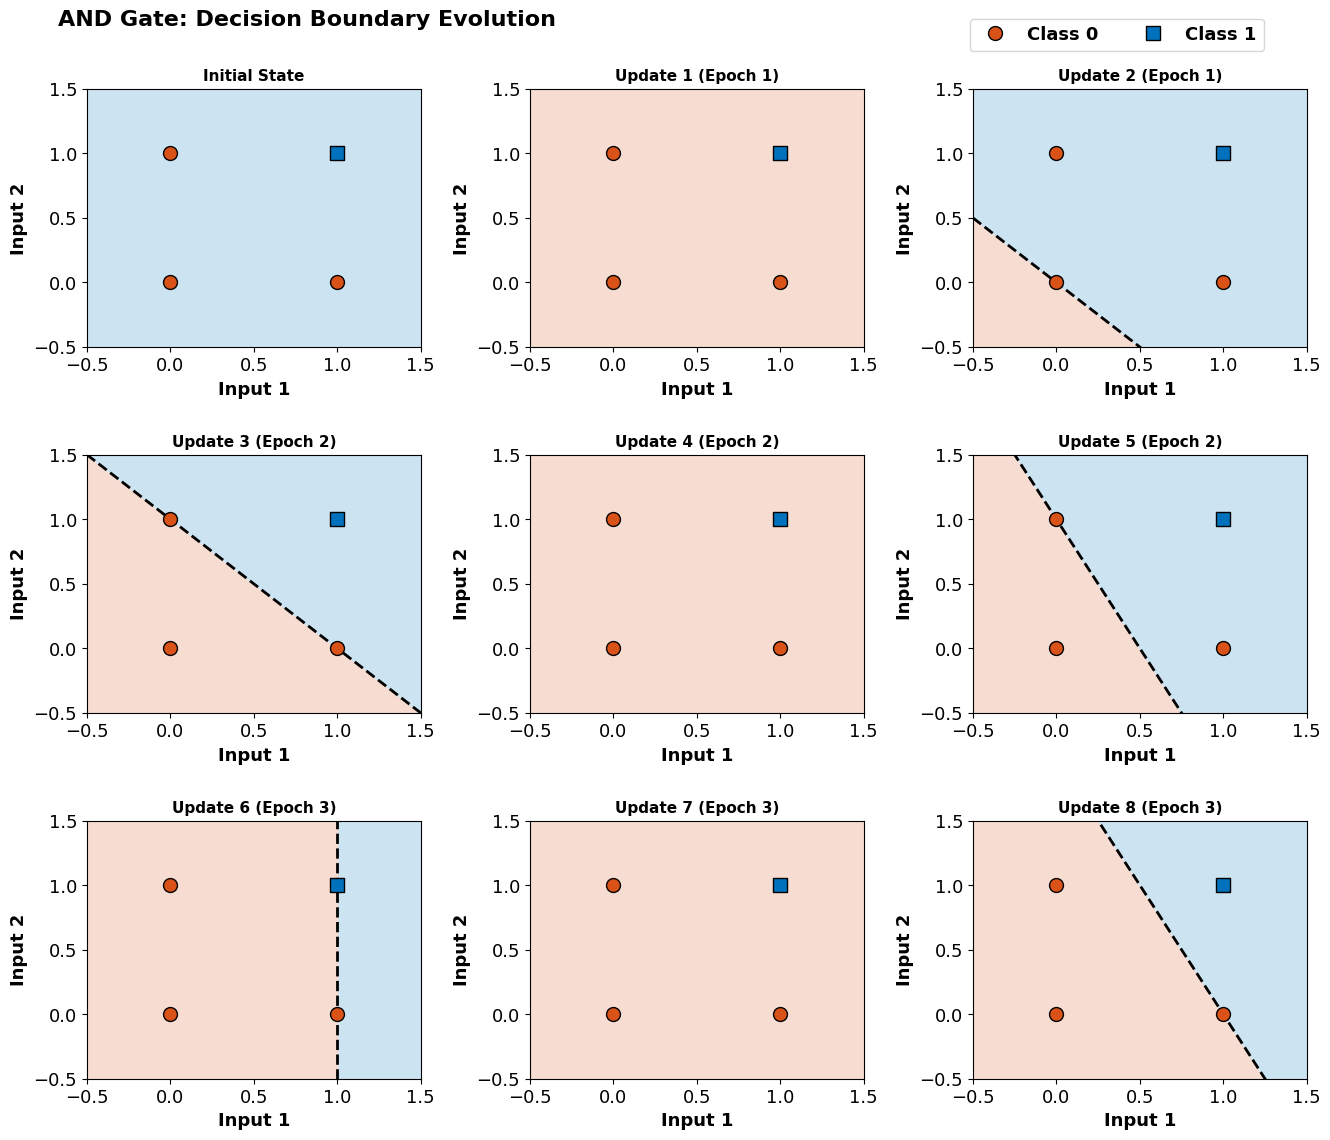

--- Training SLP for NOT Gate ---
Update 1 : Weights = [-0.1], Bias = -0.10 | Caused by input [1]
Update 2 : Weights = [-0.1], Bias = 0.00 | Caused by input [0]
Converged at epoch 3.



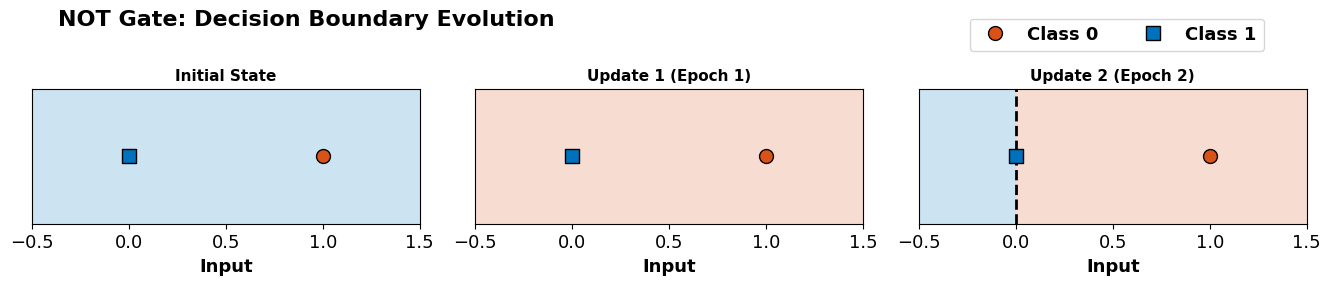

In [14]:
!apt-get install -y fonts-crosextra-carlito > /dev/null
import matplotlib.font_manager as fm
fm.findSystemFonts(fontpaths=None, fontext='ttf') # Find all system fonts and implicitly rebuild cache

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import math
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# Global Matplotlib Aesthetic Configuration
# ==========================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size'] = 13
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
legend_font = {'family': 'Times New Roman', 'size': 13, 'weight': 'bold'}

# Solid pastel colors to bypass EPS transparency limitations
light_orange = '#F7DDD1'
light_blue = '#CCE3F2'

# ==========================================
# Single-Layer Perceptron (AND, OR, NOT)
# ==========================================
class SingleLayerPerceptron:
    def __init__(self, gate_name, learning_rate=0.1, max_epochs=15):
        self.eta = learning_rate
        self.epochs = max_epochs
        self.gate_name = gate_name

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.history = [(self.w_.copy(), self.b_, "Initial State")]

        print(f"--- Training SLP for {self.gate_name} Gate ---")
        update_count = 0
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.w_) + self.b_
                y_hat = 1 if z >= 0 else 0
                update = self.eta * (target - y_hat)

                if update != 0.0:
                    self.w_ += update * xi
                    self.b_ += update
                    errors += 1
                    update_count += 1
                    self.history.append((self.w_.copy(), self.b_, f"Update {update_count} (Epoch {epoch+1})"))
                    print(f"Update {update_count:<2}: Weights = {self.w_}, Bias = {self.b_:.2f} | Caused by input {xi}")

            if errors == 0:
                print(f"Converged at epoch {epoch+1}.\n")
                break
        return self

# ==========================================
# Plotting Functions (FIXED FOR EPS)
# ==========================================
def add_global_legend(fig, x_offset=0.95, y_offset=0.95, loc='upper right'):
    handles = [
        mlines.Line2D([], [], color='#D95319', marker='o', linestyle='None', markersize=10, label='Class 0', markeredgecolor='k'),
        mlines.Line2D([], [], color='#0072BD', marker='s', linestyle='None', markersize=10, label='Class 1', markeredgecolor='k')
    ]
    fig.legend(handles=handles, prop=legend_font, loc=loc, bbox_to_anchor=(x_offset, y_offset), ncol=2)

def plot_decision_boundaries_2d(X, y, history, gate_name, filename):
    num_plots = len(history)
    cols = 3
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4.0))
    fig.suptitle(f'{gate_name} Gate: Decision Boundary Evolution', fontweight='bold', fontsize=16, x=0.05, ha='left', y=0.95)

    add_global_legend(fig)
    axes = np.array(axes).flatten() if num_plots > 1 else [axes]

    for i, (w, b, title) in enumerate(history):
        ax = axes[i]

        x1_min, x1_max = -0.5, 1.5
        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(-0.5, 1.5)

        w1, w2 = w[0], w[1]

        # Use solid light colors with alpha=1.0
        if w1 == 0 and w2 == 0:
            color = light_blue if b >= 0 else light_orange
            ax.axhspan(-0.5, 1.5, color=color, alpha=1.0, zorder=1)
        elif w2 == 0:
            x_b = -b / w1
            if w1 > 0:
                ax.axvspan(x_b, x1_max, color=light_blue, alpha=1.0, zorder=1)
                ax.axvspan(x1_min, x_b, color=light_orange, alpha=1.0, zorder=1)
            else:
                ax.axvspan(x1_min, x_b, color=light_blue, alpha=1.0, zorder=1)
                ax.axvspan(x_b, x1_max, color=light_orange, alpha=1.0, zorder=1)
            ax.axvline(x=x_b, color='k', linestyle='--', linewidth=2, zorder=2)
        else:
            xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(-0.5, 1.5, 100))
            Z = w1 * xx + w2 * yy + b
            ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], colors=[light_orange, light_blue], alpha=1.0, zorder=1)

            x_vals = np.array([x1_min, x1_max])
            y_vals = -(w1 * x_vals + b) / w2
            ax.plot(x_vals, y_vals, color='k', linestyle='--', linewidth=2, zorder=2)

        # Plot points on top
        for label, marker, color in zip([0, 1], ['o', 's'], ['#D95319', '#0072BD']):
            ax.scatter(X[y == label, 0], X[y == label, 1], marker=marker, color=color, edgecolors='k', s=100, zorder=3)

        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Input 1', fontweight='bold')
        ax.set_ylabel('Input 2', fontweight='bold')

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0, w_pad=1.0)
    plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

def plot_decision_boundaries_1d(X, y, history, gate_name, filename):
    num_plots = len(history)
    cols = min(3, num_plots)
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.0))
    fig.suptitle(f'{gate_name} Gate: Decision Boundary Evolution', fontweight='bold', fontsize=16, x=0.05, ha='left', y=0.95)

    add_global_legend(fig)
    axes = np.array(axes).flatten() if num_plots > 1 else [axes]

    for i, (w, b, title) in enumerate(history):
        ax = axes[i]

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.1, 0.1)
        ax.get_yaxis().set_visible(False)

        w1 = w[0]
        if w1 != 0:
            x_b = -b / w1
            if w1 > 0:
                ax.axvspan(x_b, 1.5, color=light_blue, alpha=1.0, zorder=1)
                ax.axvspan(-0.5, x_b, color=light_orange, alpha=1.0, zorder=1)
            else:
                ax.axvspan(-0.5, x_b, color=light_blue, alpha=1.0, zorder=1)
                ax.axvspan(x_b, 1.5, color=light_orange, alpha=1.0, zorder=1)
            ax.axvline(x=x_b, color='k', linestyle='--', linewidth=2, zorder=2)
        else:
            color = light_blue if b >= 0 else light_orange
            ax.axvspan(-0.5, 1.5, color=color, alpha=1.0, zorder=1)

        # Plot points on top
        for label, marker, color in zip([0, 1], ['o', 's'], ['#D95319', '#0072BD']):
            ax.scatter(X[y == label, 0], np.zeros(sum(y == label)), marker=marker, color=color, edgecolors='k', s=100, zorder=3)

        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Input', fontweight='bold')

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0)
    plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

# ==========================================
# Execution Data & Logic
# ==========================================

# 1. OR Gate (SLP)
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])
model_or = SingleLayerPerceptron("OR").fit(X_or, y_or)
plot_decision_boundaries_2d(X_or, y_or, model_or.history, "OR", "OR_Gate.eps")

# 2. AND Gate (SLP)
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
model_and = SingleLayerPerceptron("AND").fit(X_and, y_and)
plot_decision_boundaries_2d(X_and, y_and, model_and.history, "AND", "AND_Gate.eps")

# 3. NOT Gate (SLP)
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])
model_not = SingleLayerPerceptron("NOT").fit(X_not, y_not)
plot_decision_boundaries_1d(X_not, y_not, model_not.history, "NOT", "NOT_Gate.eps")